In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Path of Iris CSV file
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/iris.csv"
# file_path = "Z:/iris.csv" FOR THE LAB/ EXAM ENVIRONMENT
# Load CSV file
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First 5 Rows:
   Id  sepal_length  sepal_width  petal_length  petal_width species
0   1           5.1          3.5           1.4          0.2  setosa
1   2           4.9          3.0           1.4          0.2  setosa
2   3           4.7          3.2           1.3          0.2  setosa
3   4           4.6          3.1           1.5          0.2  setosa
4   5           5.0          3.6           1.4          0.2  setosa


In [4]:
# Input features
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

# Target
y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [ ]:
# As we have multiclass classification problem we need to convert (setosa, virginica) ->  label encoding (as using sparse_categorical_crossentropy)


label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("\nClass Names:")
print(label_encoder.classes_)


Class Names:
['setosa' 'versicolor' 'virginica']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (120, 4)
Testing data : (30, 4)


In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(4,)),

    tf.keras.layers.Dense(32),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(16),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                160       
                                                                 
 batch_normalization (BatchN  (None, 32)               128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 batch_normalization_1 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 16)                0

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
6/6 [==============================] - 1s 92ms/step - loss: 1.2047 - accuracy: 0.4792 - val_loss: 1.0959 - val_accuracy: 0.3333
Epoch 2/20
6/6 [==============================] - 0s 12ms/step - loss: 1.0789 - accuracy: 0.5208 - val_loss: 1.0476 - val_accuracy: 0.3333
Epoch 3/20
6/6 [==============================] - 0s 10ms/step - loss: 0.9107 - accuracy: 0.5833 - val_loss: 1.0069 - val_accuracy: 0.5000
Epoch 4/20
6/6 [==============================] - 0s 12ms/step - loss: 0.8169 - accuracy: 0.6875 - val_loss: 0.9686 - val_accuracy: 0.6667
Epoch 5/20
6/6 [==============================] - 0s 13ms/step - loss: 0.7392 - accuracy: 0.7604 - val_loss: 0.9361 - val_accuracy: 0.6667
Epoch 6/20
6/6 [==============================] - 0s 12ms/step - loss: 0.6986 - accuracy: 0.8125 - val_loss: 0.9091 - val_accuracy: 0.6667
Epoch 7/20
6/6 [==============================] - 0s 11ms/step - loss: 0.6296 - accuracy: 0.8125 - val_loss: 0.8820 - val_accuracy: 0.6667
Epoch 8/20
6/6 [===========

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy: {:.2f}%".format(
        test_accuracy * 100
    )
)

Test Loss: 0.5741990208625793
Test Accuracy: 76.67%


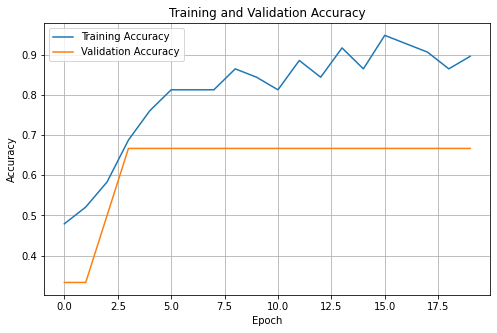

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

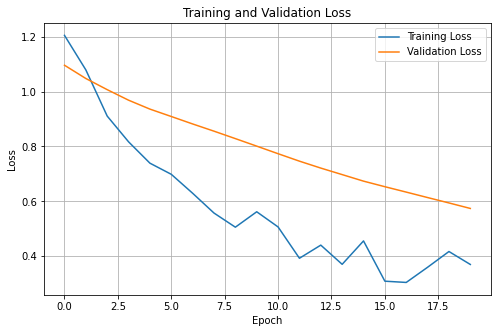

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
y_pred_probability = model.predict(X_test)

# Select class having the highest probability
y_pred = np.argmax(
    y_pred_probability,
    axis=1
)

print("Predicted Classes:")
print(y_pred)

print("\nActual Classes:")
print(y_test)

Predicted Classes:
[0 2 1 1 0 2 0 0 2 2 2 2 2 2 0 0 0 1 2 2 0 2 2 2 2 2 2 0 2 0]

Actual Classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [15]:
print("Class Mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Class Mapping:
0 = setosa
1 = versicolor
2 = virginica


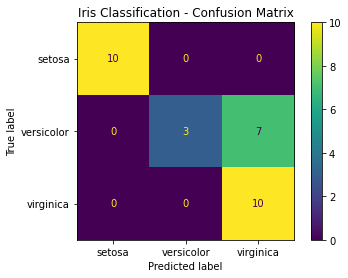

In [17]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()

plt.title("Iris Classification - Confusion Matrix")

plt.show()